In [1]:
%load_ext autoreload
%autoreload 2

import os
# Workaround for Mac M1 OpenMP conflict when loading torch
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#import pytorch_lightning as pl
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt

from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from footprinting import plot_count_matrix, average_counts_by_fraglen, get_footprint_and_procap, get_valid_windows
from datasets import FootprintDataModule
from models    import UNetLightning
from functools import partial
import wandb


In [2]:
# Define test input data 
#counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
counts_gz = '../test_data/mesc_microc_test.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'

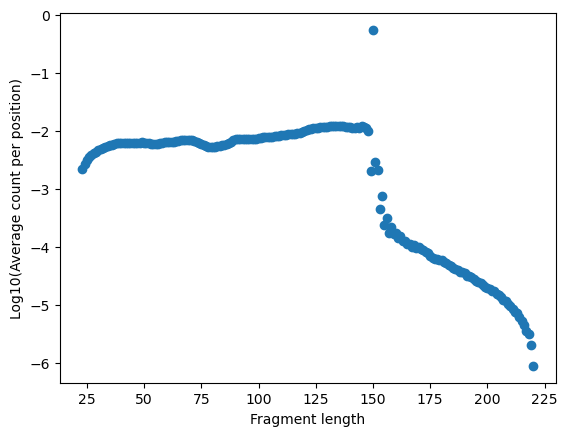

In [3]:
# Get normalization factors (i.e. average counts per fragment length)

#avg_by_len = average_counts_by_fraglen(counts_gz, chrom)

# Save avg_by_len to file
#with open('avg_by_len.pkl', 'wb') as f:
#    pickle.dump(avg_by_len, f)

# Load avg_by_len from file
with open('avg_by_len.pkl', 'rb') as f:
    avg_by_len = pickle.load(f)

# Plot log10(avg_by_len) - scatter plot
plt.scatter(avg_by_len.keys(), np.log10(list(avg_by_len.values())))
plt.xlabel('Fragment length')
plt.ylabel('Log10(Average count per position)')
plt.show()


(121, 1001) (121,) (1001,)


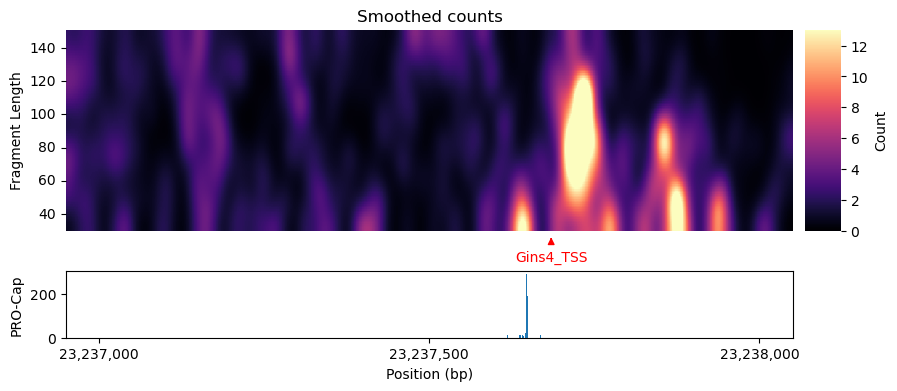

In [6]:
### Plot an example region
# Gins4 chr8:23226610-23237668 (-)

chrom = 'chr8'
start_bp = 23_237_000
end_bp = 23_238_000

#start_bp = 85_024_500
#end_bp = 85_027_500

markers = {
    23_237_668: 'Gins4_TSS'
}

footprint, raw_total_counts, procap = \
    get_footprint_and_procap(fragment_counts_gz=counts_gz, 
                                procap_bw=procap_bw,
                                avg_count_per_fragment_length=avg_by_len,
                                fragment_len_min=30, fragment_len_max=150,
                                chrom=chrom, window_start=start_bp, window_end=end_bp, footprint_sigma=10)

# Print footprint and procap shape
print(footprint.shape, raw_total_counts.shape, procap.shape)

plot_count_matrix(footprint, named_positions=markers, tracks = {'PRO-Cap': procap}, title='Smoothed counts', xtick_spacing=500)

In [6]:
# Test get_valid_windows

windows = get_valid_windows(
    counts_gz, 
    chromosomes=[('chr8', 23_237_000, 23_239_000), ('chr8', 23_300_000, 23_302_000)], 
    window_overlap_bp=0, 
    window_size=1024, 
    maxgap=1000,
    max_windows=10
)

print(windows)

[('chr8', 23237001, 23238024), ('chr8', 23300003, 23301026)]


In [7]:
# Train a model on a small dataset

# Initialize W&B run
wandb.init(project="footprint-to-procap", name="run3")

# Create the WandbLogger
wandb_logger = WandbLogger(
    project="footprint-to-procap",
    log_model=False,      # we’ll use our own checkpoint callback
)

# Create a checkpoint callback to save the best val_loss
checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="footprint-{epoch:02d}-{val_loss:.4f}",
    auto_insert_metric_name=False,
)

counts_gz = '../data/mesc_microC_3hrDMSO_chr8.counts.tsv.gz'
procap_bw = '../data/GSM2170014_Pro_mESC.ucsc_mm10.bw'

# Create training and validation windows. Exclude test region
regions = get_valid_windows(counts_gz, chromosomes=[('chr8', 0, 23_000_000), ('chr8', 24_000_000, 1e9)], 
    window_size=1024, maxgap=500)
print(f"Number of windows: {len(regions)}")
np.random.shuffle(regions)
train_regions, val_regions = regions[:int(len(regions)*0.8)], regions[int(len(regions)*0.8):]
print(f"Number of training windows: {len(train_regions)}")
print(f"Number of validation windows: {len(val_regions)}")

data_accessor_fn = partial(get_footprint_and_procap, counts_gz, procap_bw, avg_by_len)

dm = FootprintDataModule(train_regions=train_regions, val_regions=val_regions, test_regions=[], accessor_fn=data_accessor_fn, batch_size=64, num_workers=4)
model = UNetLightning(in_channels=1, base_filters=32)
trainer = Trainer(accelerator="mps", max_epochs=2, gradient_clip_val=1.0, logger=wandb_logger, callbacks=[checkpoint_cb])
trainer.fit(model, dm)

wandb.save(checkpoint_cb.best_model_path)


wandb: Currently logged in as: martin-aryee (aryeelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/martin/miniforge3/envs/tf_footprinting/lib/python3.12/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

   | Name         | Type            | Params | Mode 
----------------------------------------------------------
0  | enc1         | Sequential      | 9.7 K  | train
1  | pool1        | MaxPool2d       | 0      | train
2  | enc2         | Sequential      | 55.7 K | train
3  | pool2        | MaxPool2d       | 0      | train
4  | enc3         | Sequential      | 221 K  | train
5  | pool3        | MaxPool2d       | 0      | train
6  | enc4         | Sequential      | 886 K  | train
7  | pool4        | MaxPool2d       | 0      | train
8  | bottleneck   | Sequential      | 3.5 M 

Number of windows: 116598
Number of training windows: 93278
Number of validation windows: 23320
Epoch 1: 100%|██████████| 1458/1458 [3:49:28<00:00,  0.11it/s, v_num=kg6u, val_mu_min=2.710, val_mu_max=51.70, val_probs_min=0.0224, val_probs_max=0.398, val_loss=0.0457] 

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 1458/1458 [3:49:28<00:00,  0.11it/s, v_num=kg6u, val_mu_min=2.710, val_mu_max=51.70, val_probs_min=0.0224, val_probs_max=0.398, val_loss=0.0457]


['/Users/martin/projects/footprint-tools/code/wandb/run-20250513_130038-kn0kkg6u/files/footprint-to-procap/kn0kkg6u/checkpoints/footprint-01-0.0457.ckpt']

In [10]:
# Predict test regions

model = UNetLightning.load_from_checkpoint("/Users/martin/projects/footprint-tools/code/wandb/run-20250513_130038-kn0kkg6u/files/footprint-to-procap/kn0kkg6u/checkpoints/footprint-01-0.0457.ckpt")
trainer = Trainer(accelerator="mps")

# Create a set of test regions
test_regions = [
    ("chr8", 23_237_000, 23_238_023), # Gins4
    ("chr8", 23_208_000, 23_209_023), # Gpat4
]

data_accessor_fn = partial(get_footprint_and_procap, counts_gz, procap_bw, avg_by_len)

# turn off shuffling and set batch_size=1
dm_test = FootprintDataModule(train_regions=[], val_regions=[], test_regions=test_regions, 
                              accessor_fn=data_accessor_fn,
                              batch_size=1, num_workers=1)

dm_test.setup()
test_loader = dm_test.test_dataloader()

# run predictions
preds = trainer.predict(model, test_loader)

trues, mus, xs = [], [], []
for batch, pred in zip(test_loader, preds):
    x, y_true = batch            # y_true: (1, 1024)
    mu  = pred["mu"]             # mu: (1, 1024)
    xs.append(x.squeeze().cpu().numpy())
    trues.append(y_true.squeeze().cpu().numpy())
    mus.append(mu.squeeze().cpu().numpy())


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/martin/miniforge3/envs/tf_footprinting/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/martin/miniforge3/envs/tf_footprinting/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.30it/s]


x shape: (128, 1024)
mu shape: (1024,)
true shape: (1024,)


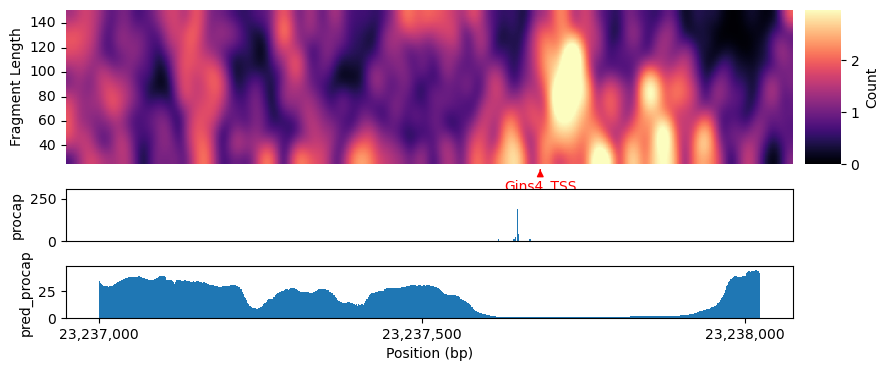

In [11]:
# View predictions

i = 0

_, start_bp, _ = test_regions[i]
x = xs[i]  # (128, 1024)
mu = mus[i]  # (1024,)
true = trues[i]  # (1024,)

print("x shape:", x.squeeze().shape)
print("mu shape:", mu.shape)
print("true shape:", true.shape)

# define your fragment‐length index and genomic‐position columns
fragment_len_min = 25
fragment_len_max = 150
frag_lens = np.arange(fragment_len_min, fragment_len_max + 1)       
positions = np.arange(1024) + start_bp    

# build the DataFrame
df_fp = pd.DataFrame(x[1:127, :], index=frag_lens, columns=positions)

# similarly make a Series for the true procap
ser_procap = pd.Series(true, index=positions)
ser_pred_procap = pd.Series(mu, index=positions)

# Gins4 chr8:23226610-23237668 (-)
markers = {
    23_237_668: 'Gins4_TSS',
    #23_237_650: 'PRO-Cap peak',
}


# now call the plotter
plot_count_matrix(
    df_fp,
    named_positions=markers,
    tracks={'procap': ser_procap, 'pred_procap': ser_pred_procap},
    xtick_spacing=500
)